## Visualize the 3 fidelities together

In [1]:
# ## Load and aggregate the three normalized metrics

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
FIDELITY_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/lka_micron")

MARGINAL_PATH = FIDELITY_DIR / "emd_gen_true_normalized.csv"
BIVARIATE_PATH = FIDELITY_DIR / "corrdiff_gen_true_normalized.csv"
JOINT_PATH = FIDELITY_DIR / "joint_emd_gen_true_normalized.csv"

marginal_df = pd.read_csv(MARGINAL_PATH)
bivariate_df = pd.read_csv(BIVARIATE_PATH)
joint_df = pd.read_csv(JOINT_PATH)

print("marginal_df:", marginal_df.shape)
print("bivariate_df:", bivariate_df.shape)
print("joint_df:", joint_df.shape)

display(marginal_df.head())
display(bivariate_df.head())
display(joint_df.head())

marginal_df: (1260, 10)
bivariate_df: (3780, 14)
joint_df: (180, 11)


,model,seed,adm1,variable,emd_distance,emd_ub,emd_lb,denom,emd_norm_raw,emd_norm
0,cNF,1,Central,vita_rae_mcg,8.045999,4.353508,108.233373,103.879865,0.035546,0.035546
1,cNF,1,Central,folate_mcg,10.974640,1.767684,67.248528,65.480844,0.140605,0.140605
2,cNF,1,Central,vitb12_mcg,0.038305,0.018204,0.653287,0.635083,0.031652,0.031652
3,cNF,1,Central,fe_mg,0.622114,0.100699,3.959306,3.858607,0.135130,0.135130
4,cNF,1,Central,zn_mg,0.367879,0.070898,2.418333,2.347435,0.126513,0.126513


,model,seed,adm1,var1,var2,pair,corr_real,corr_syn,corrdiff,corrdiff_ub,corrdiff_lb,denom,corrdiff_norm_raw,corrdiff_norm
0,cNF,1,Central,vita_rae_mcg,folate_mcg,vita_rae_mcg__folate_mcg,0.638573,0.609855,0.028718,0.000629,0.654276,0.653647,0.042972,0.042972
1,cNF,1,Central,vita_rae_mcg,vitb12_mcg,vita_rae_mcg__vitb12_mcg,0.478199,0.442145,0.036054,0.015870,0.494115,0.478245,0.042203,0.042203
2,cNF,1,Central,vita_rae_mcg,fe_mg,vita_rae_mcg__fe_mg,0.545115,0.504480,0.040635,0.001991,0.537659,0.535668,0.072143,0.072143
3,cNF,1,Central,vita_rae_mcg,zn_mg,vita_rae_mcg__zn_mg,0.464532,0.407554,0.056978,0.002927,0.479602,0.476675,0.113393,0.113393
4,cNF,1,Central,vita_rae_mcg,avg_adult_education,vita_rae_mcg__avg_adult_education,0.245312,0.212395,0.032918,0.009837,0.214526,0.204689,0.112758,0.112758


,model,seed,adm1,joint_emd,n_real,n_syn,emd_ub,emd_lb,denom,emd_norm_raw,emd_norm
0,cNF,1,Central,0.840528,2521,2521,0.361934,1.894431,1.532497,0.312297,0.312297
1,cNF,1,Eastern,0.911067,1936,1936,0.401506,1.655918,1.254412,0.406215,0.406215
2,cNF,1,North Central,1.072290,1207,1207,0.429034,1.773445,1.344411,0.478467,0.478467
3,cNF,1,North Western,0.935004,1890,1890,0.407568,1.615212,1.207643,0.436747,0.436747
4,cNF,1,Northern,0.931082,2002,2002,0.407319,1.863381,1.456061,0.359712,0.359712


In [3]:
# Average marginal over variables for each (model, seed, adm1)
marginal_avg = (
    marginal_df
    .groupby(["model", "seed", "adm1"], as_index=False)
    .agg(
        marginal_norm=("emd_norm", "mean")
    )
)

# Average bivariate over pairs for each (model, seed, adm1)
bivariate_avg = (
    bivariate_df
    .groupby(["model", "seed", "adm1"], as_index=False)
    .agg(
        bivariate_norm=("corrdiff_norm", "mean")
    )
)

# Joint is already one value per (model, seed, adm1)
joint_avg = (
    joint_df[["model", "seed", "adm1", "emd_norm"]]
    .rename(columns={"emd_norm": "joint_norm"})
    .copy()
)

display(marginal_avg.head())
display(bivariate_avg.head())
display(joint_avg.head())

,model,seed,adm1,marginal_norm
0,CTGAN,1,Central,0.282612
1,CTGAN,1,Eastern,0.322628
2,CTGAN,1,North Central,0.230503
3,CTGAN,1,North Western,0.179030
4,CTGAN,1,Northern,0.353802


,model,seed,adm1,bivariate_norm
0,CTGAN,1,Central,0.430817
1,CTGAN,1,Eastern,0.400890
2,CTGAN,1,North Central,0.295051
3,CTGAN,1,North Western,0.284270
4,CTGAN,1,Northern,0.389728


,model,seed,adm1,joint_norm
0,cNF,1,Central,0.312297
1,cNF,1,Eastern,0.406215
2,cNF,1,North Central,0.478467
3,cNF,1,North Western,0.436747
4,cNF,1,Northern,0.359712


In [4]:
# Merge the 3 metrics so each row is one (model, seed, adm1)
metrics_3way = (
    marginal_avg
    .merge(bivariate_avg, on=["model", "seed", "adm1"], how="inner")
    .merge(joint_avg, on=["model", "seed", "adm1"], how="inner")
    .copy()
)

print("metrics_3way shape:", metrics_3way.shape)
display(metrics_3way.head())

metrics_3way shape: (180, 6)


,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,Central,0.282612,0.430817,0.691453
1,CTGAN,1,Eastern,0.322628,0.400890,0.854275
2,CTGAN,1,North Central,0.230503,0.295051,0.797579
3,CTGAN,1,North Western,0.179030,0.284270,0.737321
4,CTGAN,1,Northern,0.353802,0.389728,0.856320


In [5]:
# Optional: save merged table
OUT_PATH = FIDELITY_DIR / "merged_marginal_bivariate_joint_normalized.csv"
metrics_3way.to_csv(OUT_PATH, index=False)
print(f"Saved merged table to: {OUT_PATH}")

Saved merged table to: /data/shared/fsibilla/clean_code/Q0/fidelity/lka_micron/merged_marginal_bivariate_joint_normalized.csv


In [6]:
# ## Prepare radar-plot summary
#
# We want:
# - for each model and seed: average across adm1
# - then across seeds: mean
# - and std based on the adm1-level variability after seed averaging

METRIC_COLS = ["marginal_norm", "bivariate_norm", "joint_norm"]

# Mean over adm1 within each seed
seed_level = (
    metrics_3way
    .groupby(["model", "seed"], as_index=False)[METRIC_COLS]
    .mean()
)

display(seed_level.head())

,model,seed,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,0.276936,0.365791,0.794994
1,CTGAN,2,0.349071,0.378960,0.827659
2,CTGAN,3,0.313223,0.337734,0.798809
3,CTGAN,4,0.226926,0.443785,0.656759
4,CTGAN,5,0.275663,0.474041,0.692693


In [7]:
# Mean and std across seeds for the central line
model_mean_std = (
    seed_level
    .groupby("model", as_index=False)
    .agg(
        marginal_mean=("marginal_norm", "mean"),
        marginal_std_seed=("marginal_norm", "std"),
        bivariate_mean=("bivariate_norm", "mean"),
        bivariate_std_seed=("bivariate_norm", "std"),
        joint_mean=("joint_norm", "mean"),
        joint_std_seed=("joint_norm", "std"),
    )
)

model_mean_std = model_mean_std.fillna(0.0)
display(model_mean_std)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed
0,CTGAN,0.288364,0.045743,0.400062,0.056765,0.754183,0.074713
1,NF,0.021421,0.003171,0.131371,0.006631,0.332939,0.003242
2,TVAE,0.429965,0.175414,0.517300,0.023951,0.757583,0.174954
3,cNF,0.061033,0.018229,0.148731,0.020146,0.365787,0.013257


In [8]:
# Std over adm1:
# first average across seeds for each (model, adm1), then compute std across adm1

adm1_level = (
    metrics_3way
    .groupby(["model", "adm1"], as_index=False)[METRIC_COLS]
    .mean()
)

model_adm1_std = (
    adm1_level
    .groupby("model", as_index=False)
    .agg(
        marginal_std_adm1=("marginal_norm", "std"),
        bivariate_std_adm1=("bivariate_norm", "std"),
        joint_std_adm1=("joint_norm", "std"),
    )
)

model_adm1_std = model_adm1_std.fillna(0.0)
display(model_adm1_std)

,model,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.040731,0.055263,0.066319
1,NF,0.004680,0.019793,0.038069
2,TVAE,0.136236,0.049032,0.116427
3,cNF,0.010604,0.022516,0.049789


In [9]:
# Final table for plotting
radar_df = (
    model_mean_std
    .merge(model_adm1_std, on="model", how="left")
    .fillna(0.0)
)

display(radar_df)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.288364,0.045743,0.400062,0.056765,0.754183,0.074713,0.040731,0.055263,0.066319
1,NF,0.021421,0.003171,0.131371,0.006631,0.332939,0.003242,0.004680,0.019793,0.038069
2,TVAE,0.429965,0.175414,0.517300,0.023951,0.757583,0.174954,0.136236,0.049032,0.116427
3,cNF,0.061033,0.018229,0.148731,0.020146,0.365787,0.013257,0.010604,0.022516,0.049789


In [10]:
# ## Spider / radar plot

MODEL_ORDER = ["cNF", #"NF", 
"TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in radar_df["model"].unique()]

MODEL_COLORS = {
    "cNF": "tab:blue",
    "NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

AXES_LABELS = ["Marginal", "Bivariate", "Joint"]
N_AXES = len(AXES_LABELS)

angles = np.linspace(0, 2 * np.pi, N_AXES, endpoint=False).tolist()
angles += angles[:1]  # close polygon

In [11]:
def close_vals(vals):
    vals = list(vals)
    return vals + vals[:1]

In [12]:
# Convert normalized errors into normalized fidelity scores
radar_score_df = radar_df.copy()

for col in [
    "marginal_mean", "bivariate_mean", "joint_mean",
]:
    radar_score_df[col] = 1.0 - radar_score_df[col]

display(radar_score_df)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.711636,0.045743,0.599938,0.056765,0.245817,0.074713,0.040731,0.055263,0.066319
1,NF,0.978579,0.003171,0.868629,0.006631,0.667061,0.003242,0.004680,0.019793,0.038069
2,TVAE,0.570035,0.175414,0.482700,0.023951,0.242417,0.174954,0.136236,0.049032,0.116427
3,cNF,0.938967,0.018229,0.851269,0.020146,0.634213,0.013257,0.010604,0.022516,0.049789


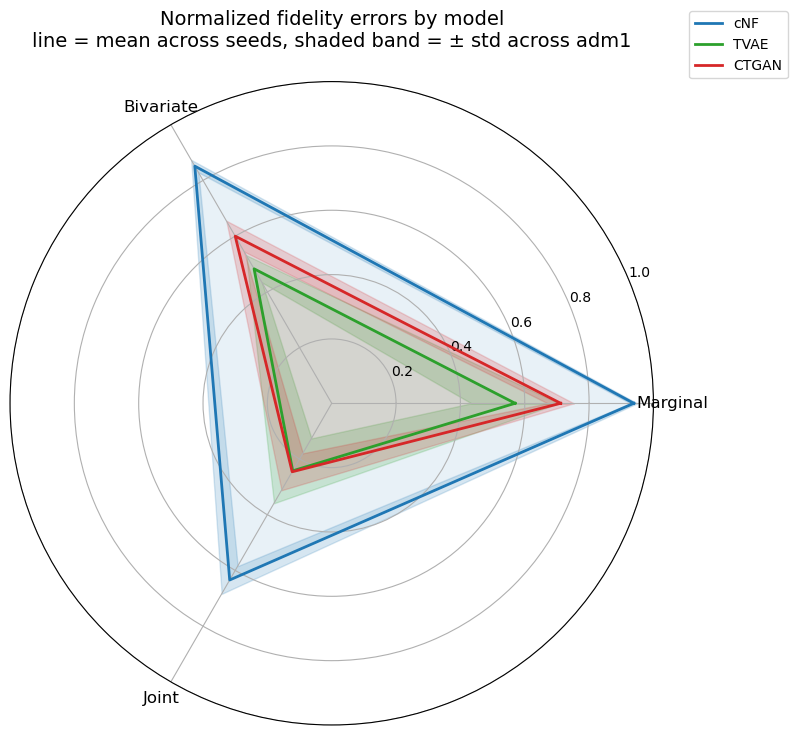

In [13]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for model in MODEL_ORDER:
    row = radar_score_df.loc[radar_score_df["model"] == model]
    if row.empty:
        continue
    row = row.iloc[0]

    means = [
        row["marginal_mean"],
        row["bivariate_mean"],
        row["joint_mean"],
    ]

    stds_adm1 = [
        row["marginal_std_adm1"],
        row["bivariate_std_adm1"],
        row["joint_std_adm1"],
    ]

    lower = np.clip(np.array(means) - np.array(stds_adm1), 0, 1)
    upper = np.clip(np.array(means) + np.array(stds_adm1), 0, 1)

    means_c = close_vals(means)
    lower_c = close_vals(lower)
    upper_c = close_vals(upper)

    color = MODEL_COLORS.get(model, "gray")

    ax.plot(
        angles,
        means_c,
        color=color,
        linewidth=2,
        label=model,
    )

    ax.fill(
        angles,
        means_c,
        color=color,
        alpha=0.10,
    )

    ax.fill_between(
        angles,
        lower_c,
        upper_c,
        color=color,
        alpha=0.18,
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(AXES_LABELS, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"])
ax.set_title(
    "Normalized fidelity errors by model\nline = mean across seeds, shaded band = ± std across adm1",
    pad=25,
    fontsize=14
)
ax.legend(loc="upper right", bbox_to_anchor=(1.22, 1.12))

plt.tight_layout()
plt.show()

## Look at originality too

In [16]:
# ## Load fidelity + recall

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
FIDELITY_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/lka_micron")
RECALL_DIR = Path("/data/shared/fsibilla/clean_code/Q0/recall/lka_micron")

FIDELITY_3WAY_PATH = FIDELITY_DIR / "merged_marginal_bivariate_joint_normalized.csv"
RECALL_PATH = RECALL_DIR / "recall_gen_true_by_adm1.csv"

fidelity_3way = pd.read_csv(FIDELITY_3WAY_PATH)
recall_df = pd.read_csv(RECALL_PATH)

print("fidelity_3way:", fidelity_3way.shape)
print("recall_df:", recall_df.shape)

display(fidelity_3way.head())
display(recall_df.head())

fidelity_3way: (180, 6)
recall_df: (180, 8)


,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,Central,0.282612,0.430817,0.691453
1,CTGAN,1,Eastern,0.322628,0.400890,0.854275
2,CTGAN,1,North Central,0.230503,0.295051,0.797579
3,CTGAN,1,North Western,0.179030,0.284270,0.737321
4,CTGAN,1,Northern,0.353802,0.389728,0.856320


,model,seed,adm1,recall,matched_real,n_real,n_syn,radius
0,cNF,1,Central,0.373661,942,2521,2521,0.5
1,cNF,1,Eastern,0.128099,248,1936,1936,0.5
2,cNF,1,North Central,0.168186,203,1207,1207,0.5
3,cNF,1,North Western,0.165608,313,1890,1890,0.5
4,cNF,1,Northern,0.151848,304,2002,2002,0.5


In [18]:
# Average the 3 fidelity metrics into one fidelity score (still an error, so lower is better)
fidelity_3way = fidelity_3way.copy()

fidelity_3way["fidelity_mean"] = fidelity_3way[
    ["marginal_norm", "bivariate_norm", "joint_norm"]
].mean(axis=1)

display(fidelity_3way.head())

,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm,fidelity_mean
0,CTGAN,1,Central,0.282612,0.430817,0.691453,0.468294
1,CTGAN,1,Eastern,0.322628,0.400890,0.854275,0.525931
2,CTGAN,1,North Central,0.230503,0.295051,0.797579,0.441044
3,CTGAN,1,North Western,0.179030,0.284270,0.737321,0.400207
4,CTGAN,1,Northern,0.353802,0.389728,0.856320,0.533283


In [19]:
# Keep only the columns needed for the merge
fidelity_for_merge = fidelity_3way[
    ["model", "seed", "adm1", "fidelity_mean"]
].copy()

recall_for_merge = recall_df[
    ["model", "seed", "adm1", "recall"]
].copy()

plot_source = (
    fidelity_for_merge
    .merge(recall_for_merge, on=["model", "seed", "adm1"], how="inner")
    .copy()
)

print("plot_source shape:", plot_source.shape)
display(plot_source.head())

plot_source shape: (180, 5)


,model,seed,adm1,fidelity_mean,recall
0,CTGAN,1,Central,0.468294,0.151527
1,CTGAN,1,Eastern,0.525931,0.054752
2,CTGAN,1,North Central,0.441044,0.091964
3,CTGAN,1,North Western,0.400207,0.075661
4,CTGAN,1,Northern,0.533283,0.052448


In [20]:
# One scatter point per model with x/y std dev error bars
model_summary = (
    plot_source
    .groupby("model", as_index=False)
    .agg(
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        fidelity_mean=("fidelity_mean", "mean"),
        fidelity_std=("fidelity_mean", "std"),
        n_rows=("recall", "count"),
    )
)

model_summary["recall_std"] = model_summary["recall_std"].fillna(0.0)
model_summary["fidelity_std"] = model_summary["fidelity_std"].fillna(0.0)

display(model_summary)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows
0,CTGAN,0.105057,0.036465,0.480870,0.055783,45
1,NF,0.260256,0.092486,0.161910,0.021054,45
2,TVAE,0.152297,0.104398,0.571648,0.159967,45
3,cNF,0.242943,0.099992,0.191850,0.031680,45


In [21]:
MODEL_ORDER = ["cNF", #"NF",
 "TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in model_summary["model"].unique()]

MODEL_COLORS = {
    "cNF": "tab:blue",
    #"NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

model_summary = (
    model_summary
    .set_index("model")
    .loc[MODEL_ORDER]
    .reset_index()
)

display(model_summary)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows
0,cNF,0.242943,0.099992,0.191850,0.031680,45
1,TVAE,0.152297,0.104398,0.571648,0.159967,45
2,CTGAN,0.105057,0.036465,0.480870,0.055783,45


In [22]:
model_summary_plot = model_summary.copy()
model_summary_plot["fidelity_score"] = 1.0 - model_summary_plot["fidelity_mean"]

display(model_summary_plot)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows,fidelity_score
0,cNF,0.242943,0.099992,0.191850,0.031680,45,0.808150
1,TVAE,0.152297,0.104398,0.571648,0.159967,45,0.428352
2,CTGAN,0.105057,0.036465,0.480870,0.055783,45,0.519130


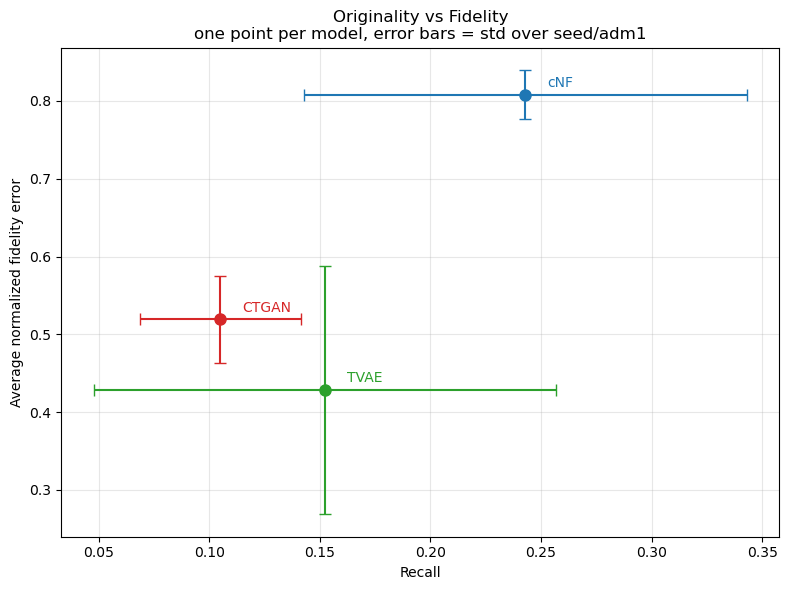

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in model_summary_plot.iterrows():
    model = row["model"]
    x = row["recall_mean"]
    y = row["fidelity_score"]
    xerr = row["recall_std"]
    yerr = row["fidelity_std"]
    color = MODEL_COLORS.get(model, "gray")

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        yerr=yerr,
        fmt="o",
        capsize=4,
        markersize=8,
        color=color,
        ecolor=color,
        elinewidth=1.5,
        label=model,
    )

    ax.text(
        x + 0.01,
        y + 0.01,
        model,
        fontsize=10,
        color=color,
    )

ax.set_xlabel("Recall")
ax.set_ylabel("Average normalized fidelity error")
ax.set_title("Originality vs Fidelity\none point per model, error bars = std over seed/adm1")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()